In [1]:
# ---------------------------
# Import Required Libraries
# ---------------------------

import pandas as pd
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Balancing
from imblearn.over_sampling import SMOTE

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Save model
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [2]:

# Load dataset
data = pd.read_csv("/content/diabetes.csv")   # change path if needed

print("Dataset Shape:", data.shape)
data.head()


Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Data Info:\n")
print(data.info())

print("\nSummary Statistics:\n")
print(data.describe().T)

print("\nZero Value Counts (important for cleaning):")
cols_with_zero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_with_zero:
    print(f"{col}: {(data[col] == 0).sum()}")


Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Summary Statistics:

                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   3

In [4]:
df = data.copy()

# Replace zeros with NaN
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

# Median Imputation
for col in cols_with_zero:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"{col}: Replaced missing with median = {median_val}")

df.isna().sum()


Glucose: Replaced missing with median = 117.0
BloodPressure: Replaced missing with median = 72.0
SkinThickness: Replaced missing with median = 29.0
Insulin: Replaced missing with median = 125.0
BMI: Replaced missing with median = 32.3


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)
print("\nClass Distribution:\n", y.value_counts())


X Shape: (768, 8)
y Shape: (768,)

Class Distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64


In [6]:
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

print("After SMOTE Class Distribution:\n", y_bal.value_counts())


After SMOTE Class Distribution:
 Outcome
1    500
0    500
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training Shape:", X_train_scaled.shape)
print("Testing Shape:", X_test_scaled.shape)



Training Shape: (800, 8)
Testing Shape: (200, 8)


In [8]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy: {:.2f}%".format(acc_rf * 100))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 83.50%

Confusion Matrix:
 [[79 21]
 [12 88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.79      0.83       100
           1       0.81      0.88      0.84       100

    accuracy                           0.83       200
   macro avg       0.84      0.83      0.83       200
weighted avg       0.84      0.83      0.83       200



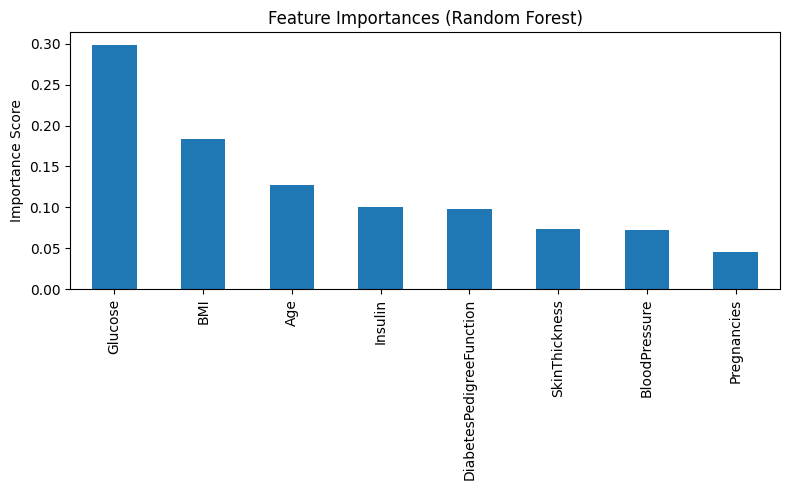

,0
Glucose,0.299244
BMI,0.183309
Age,0.127716
Insulin,0.100804
DiabetesPedigreeFunction,0.098309
SkinThickness,0.073675
BloodPressure,0.071740
Pregnancies,0.045203


In [9]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.plot(kind="bar")
plt.title("Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

feat_imp


In [10]:
joblib.dump(rf, "rf_diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("RF Model and scaler saved successfully!")



RF Model and scaler saved successfully!


In [11]:
import joblib
import numpy as np

# Load your REAL saved files
model = joblib.load("rf_diabetes_model.pkl")
scaler = joblib.load("scaler.pkl")

print("Model and scaler loaded successfully!")


Model and scaler loaded successfully!


In [12]:
def predict_diabetes_stage(features):

    features = np.array([features])

    # Scale input
    scaled = scaler.transform(features)

    # Predict class
    pred = model.predict(scaled)[0]
    prob = model.predict_proba(scaled)[0][1] * 100

    # Diabetes or not
    result = "Diabetic" if pred == 1 else "Non-Diabetic"

    # Stage Classification (based on Glucose)
    Glucose = features[0][1]

    if pred == 0:
        stage = "No Diabetes"
    else:
        if Glucose < 140:
            stage = "Mild Diabetes"
        elif 140 <= Glucose < 200:
            stage = "Moderate Diabetes"
        else:
            stage = "Severe Diabetes"

    return result, stage, round(prob, 2)


In [13]:
print("Enter patient details:\n")

Pregnancies = float(input("Pregnancies: "))
Glucose = float(input("Glucose: "))
BloodPressure = float(input("BloodPressure: "))
SkinThickness = float(input("SkinThickness: "))
Insulin = float(input("Insulin: "))
BMI = float(input("BMI: "))
DiabetesPedigreeFunction = float(input("DiabetesPedigreeFunction: "))
Age = float(input("Age: "))

# User Input Array
user_input = [
    Pregnancies, Glucose, BloodPressure, SkinThickness,
    Insulin, BMI, DiabetesPedigreeFunction, Age
]

# Prediction
result, stage, prob = predict_diabetes_stage(user_input)

print("\n================================")
print("        PREDICTION RESULT")
print("================================")
print("Diabetes Status:", result)
print("Stage:", stage)
print("Probability of Diabetes:", prob, "%")


Enter patient details:

Pregnancies: 2
Glucose: 70
BloodPressure: 45
SkinThickness: 45
Insulin: 160
BMI: 67
DiabetesPedigreeFunction: 0.231
Age: 56

        PREDICTION RESULT
Diabetes Status: Non-Diabetic
Stage: No Diabetes
Probability of Diabetes: 41.02 %


In [16]:
!pip install gradio scikit-learn xgboost imbalanced-learn joblib -q

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings("ignore")

data = pd.read_csv("diabetes.csv")

df = data.copy()
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
for col in cols_with_zero:
    df[col].fillna(df[col].median(), inplace=True)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=400, max_depth=8,
                            min_samples_split=3, min_samples_leaf=2,
                            random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

joblib.dump(rf, "rf_diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("✅ Model and scaler saved!")

✅ Model and scaler saved!


In [22]:
import gradio as gr
import joblib
import numpy as np

model  = joblib.load("rf_diabetes_model.pkl")
scaler = joblib.load("scaler.pkl")

# ── Prediction logic ─────────────────────────────────────────────────────────
def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness,
                     insulin, bmi, dpf, age):

    # Input validation
    for name, val in [("Pregnancies", pregnancies), ("Glucose", glucose),
                      ("Blood Pressure", blood_pressure), ("Skin Thickness", skin_thickness),
                      ("Insulin", insulin), ("BMI", bmi), ("DPF", dpf), ("Age", age)]:
        if val is None or str(val).strip() == "":
            return (f"⚠ Please enter a value for {name}.", "", "", "", "")

    try:
        p  = float(pregnancies)
        g  = float(glucose)
        bp = float(blood_pressure)
        st = float(skin_thickness)
        ins = float(insulin)
        b  = float(bmi)
        d  = float(dpf)
        a  = float(age)
    except:
        return ("⚠ All inputs must be valid numbers.", "", "", "", "")

    features = np.array([[p, g, bp, st, ins, b, d, a]])
    scaled   = scaler.transform(features)
    pred     = model.predict(scaled)[0]
    prob     = round(model.predict_proba(scaled)[0][1] * 100, 2)
    non_prob = round(100 - prob, 2)

    result = "Diabetic" if pred == 1 else "Non-Diabetic"

    if pred == 0:
        stage = "No Diabetes"
    elif g < 140:
        stage = "Mild Diabetes"
    elif g < 200:
        stage = "Moderate Diabetes"
    else:
        stage = "Severe Diabetes"

    icon = "🔴" if pred == 1 else "🟢"

    # Page 1 — Summary output
    summary = f"""{icon} PREDICTION RESULT
{'─' * 35}
  Status       :  {result}
  Stage        :  {stage}
  Probability  :  {prob}%  (Diabetic)
               :  {non_prob}%  (Non-Diabetic)
{'─' * 35}"""

    # Page 2 — Risk factors
    risks = []
    if g > 140:    risks.append(f"  ⚠  High glucose level        →  {g} mg/dL  (normal: 70–140)")
    if g > 100:    risks.append(f"  ⚠  Pre-diabetic glucose range →  {g} mg/dL  (ideal: <100 fasting)")
    if b > 30:     risks.append(f"  ⚠  Obese BMI                 →  {b:.1f}  (normal: 18.5–24.9)")
    elif b > 25:   risks.append(f"  ⚠  Overweight BMI            →  {b:.1f}  (normal: 18.5–24.9)")
    if a > 45:     risks.append(f"  ⚠  Age above 45              →  {int(a)} years  (higher risk group)")
    if d > 0.5:    risks.append(f"  ⚠  High pedigree function    →  {d}  (hereditary risk elevated)")
    if bp > 90:    risks.append(f"  ⚠  High blood pressure       →  {bp} mmHg  (normal diastolic: <80)")
    if ins > 166:  risks.append(f"  ⚠  High insulin level        →  {ins} µU/mL  (normal: 16–166)")
    if p > 5:      risks.append(f"  ⚠  High pregnancy count      →  {int(p)}  (risk increases >5)")
    if not risks:  risks.append("  ✅  No major individual risk factors detected")

    risk_text = "\n".join(risks)

    # Page 2 — Input summary table
    input_summary = f"""  ENTERED PATIENT VALUES
{'─' * 35}
  Pregnancies          :  {int(p)}
  Glucose              :  {g} mg/dL
  Blood Pressure       :  {bp} mmHg
  Skin Thickness       :  {st} mm
  Insulin              :  {ins} µU/mL
  BMI                  :  {b:.1f} kg/m²
  Pedigree Function    :  {d}
  Age                  :  {int(a)} years
{'─' * 35}"""

    # Page 2 — Interpretation
    if pred == 1:
        interp = (
            f"The Random Forest model predicts DIABETIC with {prob}% probability.\n"
            f"Glucose level of {g} mg/dL classifies this as '{stage}'.\n"
            f"BMI of {b:.1f} and age {int(a)} are contributing risk factors.\n"
            "⚕  Please consult a physician for clinical confirmation."
        )
    else:
        interp = (
            f"The Random Forest model predicts NON-DIABETIC with {non_prob}% confidence.\n"
            f"Glucose level {g} mg/dL and BMI {b:.1f} appear within manageable range.\n"
            "✅ Maintain a healthy diet and regular exercise to keep risk low.\n"
            "⚕  Routine checkups are still recommended."
        )

    return summary, risk_text, input_summary, interp, gr.update(visible=True)


def clear_all():
    return ("", "", "", "", "", "", "", "",
            "", "", "", "", gr.update(visible=False))


# ── CSS theme ─────────────────────────────────────────────────────────────────
custom_css = """
.gradio-container { font-family: 'Segoe UI', sans-serif !important; }
#title-text { text-align: center; }
#predict-btn { background: #1d4ed8 !important; color: white !important;
               font-size: 16px !important; padding: 12px !important; }
#clear-btn   { font-size: 14px !important; }
.tab-nav button { font-size: 15px !important; font-weight: 600 !important; }
"""

# ── Build UI ──────────────────────────────────────────────────────────────────
with gr.Blocks(css=custom_css, title="Diabetes Risk Predictor",
               theme=gr.themes.Soft(primary_hue="blue")) as app:

    # ── Header ────────────────────────────────────────────────────────────────
    gr.Markdown("""
    <h1 id='title-text'>🩺 Diabetes Risk Predictor</h1>
    <p style='text-align:center; color:gray;'>
    Mini Project &nbsp;|&nbsp; Random Forest ML Model &nbsp;|&nbsp;
    <b>Type patient values → click Predict</b>
    </p>
    <hr>
    """)

    # ── Two pages as Tabs ─────────────────────────────────────────────────────
    with gr.Tabs():

        # ════════════════════════════════════════════════
        # PAGE 1 — Input + Prediction Result
        # ════════════════════════════════════════════════
        with gr.Tab("📝  Page 1 — Patient Input & Result"):

            gr.Markdown("### Enter Patient Details")

            with gr.Row():
                with gr.Column():
                    pregnancies    = gr.Textbox(label="Pregnancies",
                                                placeholder="e.g.  2",
                                                info="Number of times pregnant (0–20)")
                    glucose        = gr.Textbox(label="Glucose (mg/dL)",
                                                placeholder="e.g.  120",
                                                info="Plasma glucose concentration")
                    blood_pressure = gr.Textbox(label="Blood Pressure (mmHg)",
                                                placeholder="e.g.  72",
                                                info="Diastolic blood pressure")
                    skin_thickness = gr.Textbox(label="Skin Thickness (mm)",
                                                placeholder="e.g.  23",
                                                info="Triceps skin fold thickness")

                with gr.Column():
                    insulin = gr.Textbox(label="Insulin (µU/mL)",
                                         placeholder="e.g.  80",
                                         info="2-hour serum insulin level")
                    bmi     = gr.Textbox(label="BMI (kg/m²)",
                                         placeholder="e.g.  28.5",
                                         info="Body mass index")
                    dpf     = gr.Textbox(label="Diabetes Pedigree Function",
                                         placeholder="e.g.  0.47",
                                         info="Hereditary diabetes risk score")
                    age     = gr.Textbox(label="Age (years)",
                                         placeholder="e.g.  35",
                                         info="Patient's current age")

            with gr.Row():
                predict_btn = gr.Button("🔍  Predict Diabetes Risk",
                                        elem_id="predict-btn", variant="primary", scale=3)
                clear_btn   = gr.Button("↺  Clear All",
                                        elem_id="clear-btn", variant="secondary", scale=1)

            gr.Markdown("---")
            gr.Markdown("### 📊 Prediction Result")

            result_out = gr.Textbox(label="Result Summary",
                                    lines=7, interactive=False,
                                    show_copy_button=True)

        # ════════════════════════════════════════════════
        # PAGE 2 — Detailed Report
        # ════════════════════════════════════════════════
        with gr.Tab("📋  Page 2 — Detailed Report"):

            report_visible = gr.State(False)

            gr.Markdown("### 🧾 Full Prediction Report")
            gr.Markdown("> Run a prediction on Page 1 first — results appear here automatically.")

            result_page2 = gr.Column(visible=False)

            with result_page2:
                with gr.Row():
                    with gr.Column():
                        input_summary_out = gr.Textbox(
                            label="Patient Values Entered",
                            lines=12, interactive=False,
                            show_copy_button=True)

                    with gr.Column():
                        risk_out = gr.Textbox(
                            label="Risk Factors Detected",
                            lines=12, interactive=False,
                            show_copy_button=True)

                interp_out = gr.Textbox(
                    label="Clinical Interpretation",
                    lines=5, interactive=False,
                    show_copy_button=True)

    # ── Wire buttons ──────────────────────────────────────────────────────────
    all_inputs  = [pregnancies, glucose, blood_pressure, skin_thickness,
                   insulin, bmi, dpf, age]
    all_outputs = [result_out, risk_out, input_summary_out, interp_out, result_page2]

    predict_btn.click(fn=predict_diabetes,
                      inputs=all_inputs,
                      outputs=all_outputs)

    clear_btn.click(fn=clear_all,
                    inputs=[],
                    outputs=all_inputs + [result_out, risk_out,
                                          input_summary_out, interp_out,
                                          result_page2])

# ── Launch ────────────────────────────────────────────────────────────────────
app.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8024d99264f0cbcf05.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
